# Cross-country retail trade forecasting

This case study compares a regularised linear model with a non-linear ensemble for monthly retail-sales indices across Australia, Great Britain, New Zealand, and the United States. The primary evaluation is chronological: every test observation occurs after the training and validation periods.

**Main question:** Can recent history, seasonality, country, and industry explain the next observed monthly sales index without using future information?

## Reproducible data snapshot

The repository includes an aligned CSV for local execution. A compressed copy is also embedded in this notebook so the notebook can run when opened alone in an authorised hosted notebook session. Both copies contain aggregated public statistics only.

The four sources have different latest months. To make the comparison consistent, all series use the shared period January 2005 through March 2025. Source links, licence terms, and transformations are documented in `data/README.md`.

In [1]:
from __future__ import annotations

import base64
import io
import warnings
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path(".")
if not (PROJECT_ROOT / "data" / "retail_trade_aligned.csv").exists() and (Path("..") / "data" / "retail_trade_aligned.csv").exists():
    PROJECT_ROOT = Path("..")

FIGURE_DIR = PROJECT_ROOT / "figures"
RESULT_DIR = PROJECT_ROOT / "results"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
data_path = PROJECT_ROOT / "data" / "retail_trade_aligned.csv"
if data_path.exists():
    data = pd.read_csv(data_path, parse_dates=["Date"])
    data_origin = "repository CSV"
else:
    embedded_archive = "..."
    archive_bytes = base64.b64decode(embedded_archive)
    with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
        with archive.open("retail_trade_aligned.csv") as stream:
            data = pd.read_csv(stream, parse_dates=["Date"])
    data_origin = "embedded reproducibility snapshot"

data = data.sort_values(["Country", "Industry_std", "Date"]).reset_index(drop=True)
print(f"Loaded {len(data):,} rows from the {data_origin}.")
print(f"Date range: {data['Date'].min():%Y-%m} to {data['Date'].max():%Y-%m}")
print(f"Countries: {data['Country'].nunique()} | Industries: {data['Industry_std'].nunique()}")


Loaded 5,103 rows from the repository CSV.
Date range: 2005-01 to 2025-03
Countries: 4 | Industries: 7


## Data quality and coverage

The checks below confirm the shared date window, missing-target policy, and panel size. National retail classifications are mapped to broad common industry labels. That mapping improves comparability but does not remove every difference in survey design or measurement units.

In [3]:
quality_summary = pd.DataFrame({
    "Metric": ["Rows", "Countries", "Industries", "Missing sales index", "Duplicate panel-month rows"],
    "Value": [
        len(data),
        data["Country"].nunique(),
        data["Industry_std"].nunique(),
        int(data["Sales_index"].isna().sum()),
        int(data.duplicated(["Date", "Country", "Industry_std"]).sum()),
    ],
})
display(quality_summary)

coverage = (
    data.groupby("Country")
    .agg(Start=("Date", "min"), End=("Date", "max"), Rows=("Date", "size"), Industries=("Industry_std", "nunique"))
    .reset_index()
)
coverage["Start"] = coverage["Start"].dt.strftime("%Y-%m")
coverage["End"] = coverage["End"].dt.strftime("%Y-%m")
display(coverage)


,Metric,Value
0,Rows,5103
1,Countries,4
2,Industries,7
3,Missing sales index,0
4,Duplicate panel-month rows,0


,Country,Start,End,Rows,Industries
0,Australia,2005-01,2025-03,972,4
1,Great Britain,2005-01,2025-03,1458,6
2,New Zealand,2005-01,2025-03,1215,5
3,United States,2005-01,2025-03,1458,6


## Exploratory view

Because the national series use different currencies and scales, the analysis models the 2015-based sales index rather than raw sales values. The chart shows the average index by country; industry-level variation is retained for modelling.

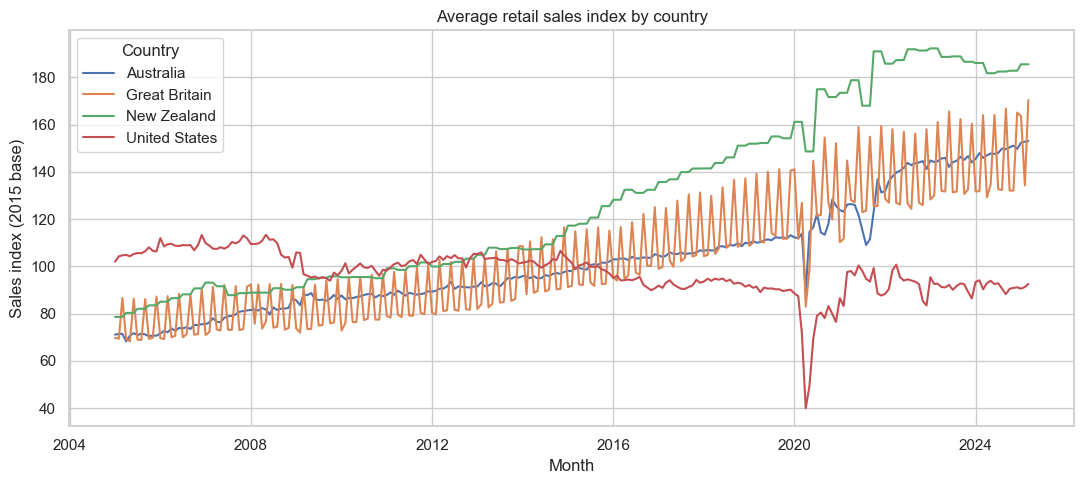

In [4]:
country_month = data.groupby(["Date", "Country"], as_index=False)["Sales_index"].mean()
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=country_month, x="Date", y="Sales_index", hue="Country", ax=ax)
ax.set(title="Average retail sales index by country", xlabel="Month", ylabel="Sales index (2015 base)")
ax.legend(title="Country", frameon=True)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "coverage.png", dpi=160, bbox_inches="tight")
plt.show()


## Leakage-safe feature engineering

Every lagged feature is calculated within a country-industry series and shifted before rolling statistics are computed. The model therefore sees only observations available before the month being predicted.

This is a **one-step-ahead, walk-forward evaluation**: the previous observed month is available when predicting the next month. It is not a recursive multi-year forecast.

In [5]:
group_keys = ["Country", "Industry_std"]
data["Month"] = data["Date"].dt.month
data["Time_index"] = (data["Date"].dt.year - data["Date"].dt.year.min()) * 12 + data["Date"].dt.month - 1
data["Month_sin"] = np.sin(2 * np.pi * data["Month"] / 12)
data["Month_cos"] = np.cos(2 * np.pi * data["Month"] / 12)
data["Lag_1"] = data.groupby(group_keys)["Sales_index"].shift(1)
data["Lag_12"] = data.groupby(group_keys)["Sales_index"].shift(12)
data["Rolling_mean_12"] = data.groupby(group_keys)["Sales_index"].transform(
    lambda series: series.shift(1).rolling(12, min_periods=12).mean()
)

model_data = data.dropna(subset=["Lag_1", "Lag_12", "Rolling_mean_12"]).copy()
print(f"Model-ready rows after lag construction: {len(model_data):,}")


Model-ready rows after lag construction: 4,851


## Chronological validation design

Random row splitting would allow later months to influence model selection and can overstate performance. This notebook uses expanding time windows for parameter selection and reserves January 2024 through March 2025 as a final untouched test period.

- Validation fold 1: train through 2018, validate on 2019-2020
- Validation fold 2: train through 2020, validate on 2021-2022
- Validation fold 3: train through 2022, validate on 2023
- Final test: January 2024 through March 2025

In [6]:
test_start = pd.Timestamp("2024-01-01")
development = model_data.loc[model_data["Date"] < test_start].copy()
test = model_data.loc[model_data["Date"] >= test_start].copy()

features = [
    "Country", "Industry_std", "Time_index", "Month_sin", "Month_cos",
    "Lag_1", "Lag_12", "Rolling_mean_12",
]
target = "Sales_index"
categorical_features = ["Country", "Industry_std"]
numeric_features = [feature for feature in features if feature not in categorical_features]

fold_windows = [
    (pd.Timestamp("2018-12-01"), pd.Timestamp("2019-01-01"), pd.Timestamp("2020-12-01")),
    (pd.Timestamp("2020-12-01"), pd.Timestamp("2021-01-01"), pd.Timestamp("2022-12-01")),
    (pd.Timestamp("2022-12-01"), pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-01")),
]
cv_splits = []
for train_end, valid_start, valid_end in fold_windows:
    train_index = np.flatnonzero((development["Date"] <= train_end).to_numpy())
    valid_index = np.flatnonzero(development["Date"].between(valid_start, valid_end).to_numpy())
    cv_splits.append((train_index, valid_index))

split_summary = pd.DataFrame({
    "Set": ["Development", "Final test"],
    "Start": [development["Date"].min(), test["Date"].min()],
    "End": [development["Date"].max(), test["Date"].max()],
    "Rows": [len(development), len(test)],
})
display(split_summary)


,Set,Start,End,Rows
0,Development,2006-01-01,2023-12-01,4536
1,Final test,2024-01-01,2025-03-01,315


## Model selection

Ridge regression provides an interpretable regularised baseline. Random Forest captures non-linear relationships and interactions. Hyperparameters are selected only with the expanding chronological folds. The final test period is used once for comparison with a seasonal-naive baseline.

In [7]:
linear_preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("numeric", StandardScaler(), numeric_features),
])
tree_preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("numeric", "passthrough", numeric_features),
])

ridge_pipeline = Pipeline([
    ("preprocess", linear_preprocessor),
    ("model", Ridge()),
])
forest_pipeline = Pipeline([
    ("preprocess", tree_preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
])

searches = {
    "Ridge": GridSearchCV(
        ridge_pipeline,
        {"model__alpha": [0.1, 1.0, 10.0, 100.0]},
        cv=cv_splits,
        scoring="neg_root_mean_squared_error",
        n_jobs=1,
    ),
    "Random Forest": GridSearchCV(
        forest_pipeline,
        {
            "model__n_estimators": [200],
            "model__max_depth": [12, None],
            "model__min_samples_leaf": [2, 5],
            "model__max_features": ["sqrt", 0.7],
        },
        cv=cv_splits,
        scoring="neg_root_mean_squared_error",
        n_jobs=1,
    ),
}

X_development, y_development = development[features], development[target]
X_test, y_test = test[features], test[target]
fitted_models = {}
for name, search in searches.items():
    search.fit(X_development, y_development)
    fitted_models[name] = search.best_estimator_
    print(f"{name}: best CV RMSE = {-search.best_score_:.3f}; parameters = {search.best_params_}")


Ridge: best CV RMSE = 13.811; parameters = {'model__alpha': 100.0}


Random Forest: best CV RMSE = 13.310; parameters = {'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 200}


In [8]:
def metrics(y_true, prediction):
    return {
        "R2": r2_score(y_true, prediction),
        "RMSE": mean_squared_error(y_true, prediction) ** 0.5,
        "MAE": mean_absolute_error(y_true, prediction),
    }

predictions = {"Seasonal naive": test["Lag_12"].to_numpy()}
predictions.update({name: model.predict(X_test) for name, model in fitted_models.items()})

metric_rows = []
for name, prediction in predictions.items():
    metric_rows.append({"Model": name, **metrics(y_test, prediction)})
model_metrics = pd.DataFrame(metric_rows).sort_values("RMSE").reset_index(drop=True)
model_metrics.to_csv(RESULT_DIR / "model_metrics.csv", index=False)
display(model_metrics.round({"R2": 3, "RMSE": 3, "MAE": 3}))


,Model,R2,RMSE,MAE
0,Random Forest,0.977,6.678,4.479
1,Seasonal naive,0.969,7.751,5.340
2,Ridge,0.959,9.003,6.192


## Final test results

The comparison below uses only months after the development period. Lower RMSE and MAE are better; higher R² is better. The seasonal-naive benchmark predicts each series from its value twelve months earlier.

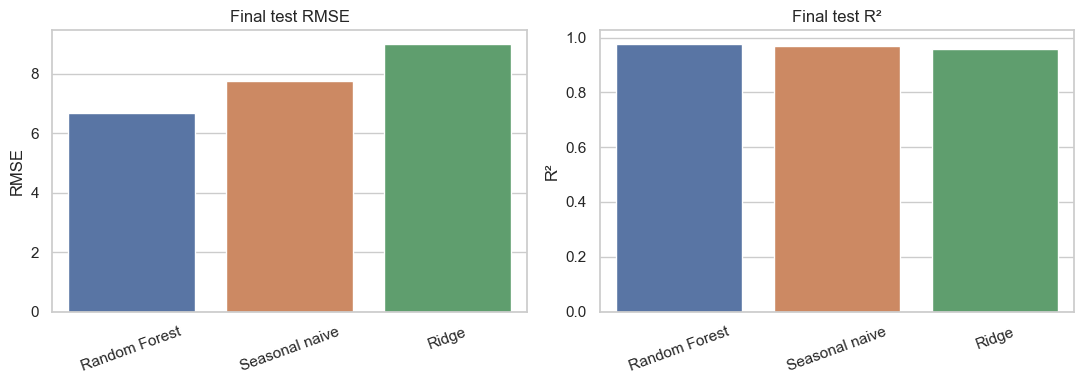

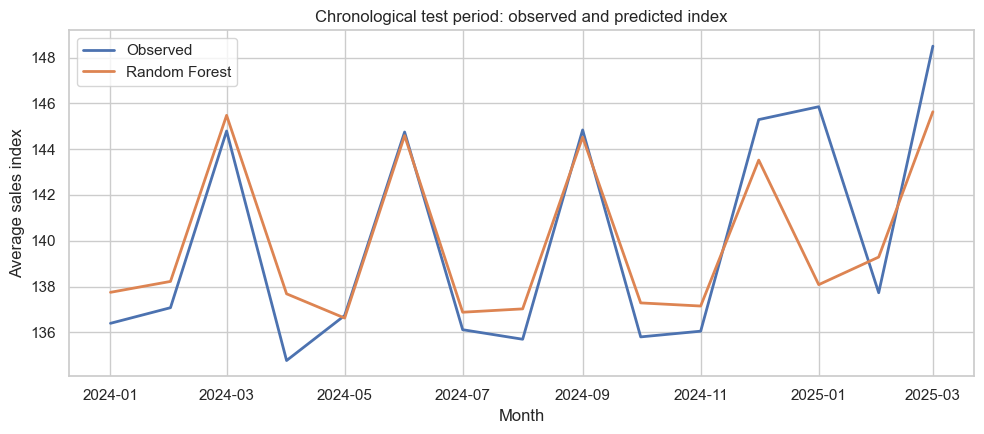

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=model_metrics, x="Model", y="RMSE", hue="Model", legend=False, ax=axes[0])
sns.barplot(data=model_metrics, x="Model", y="R2", hue="Model", legend=False, ax=axes[1])
axes[0].set(title="Final test RMSE", xlabel="", ylabel="RMSE")
axes[1].set(title="Final test R²", xlabel="", ylabel="R²")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

prediction_frame = test[["Date", "Country", "Industry_std", "Sales_index"]].copy()
best_model_name = model_metrics.iloc[0]["Model"]
prediction_frame["Prediction"] = predictions[best_model_name]
monthly_prediction = prediction_frame.groupby("Date", as_index=False)[["Sales_index", "Prediction"]].mean()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly_prediction["Date"], monthly_prediction["Sales_index"], label="Observed", linewidth=2)
ax.plot(monthly_prediction["Date"], monthly_prediction["Prediction"], label=best_model_name, linewidth=2)
ax.set(title="Chronological test period: observed and predicted index", xlabel="Month", ylabel="Average sales index")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "test_predictions.png", dpi=160, bbox_inches="tight")
plt.show()


## Performance by country

Aggregate metrics can hide weak performance in a particular market. The table below reports the selected model separately for each country so geographic variation remains visible.

In [10]:
country_rows = []
for country, country_data in prediction_frame.groupby("Country"):
    country_rows.append({
        "Country": country,
        **metrics(country_data["Sales_index"], country_data["Prediction"]),
        "Rows": len(country_data),
    })
country_metrics = pd.DataFrame(country_rows).sort_values("RMSE")
country_metrics.to_csv(RESULT_DIR / "country_metrics.csv", index=False)
display(country_metrics.round({"R2": 3, "RMSE": 3, "MAE": 3}))


,Country,R2,RMSE,MAE,Rows
3,United States,-0.960,2.199,1.850,90
0,Australia,0.965,3.209,2.552,60
2,New Zealand,0.909,6.758,5.726,75
1,Great Britain,0.953,10.311,7.353,90


## Interpretation and limitations

The final model comparison is based on a chronological holdout, not a random row split. This removes the earlier ambiguity caused by very high random-split scores and unstable cross-validation.

Important limitations remain:

- The national datasets use different survey designs and industry classifications.
- The task predicts a harmonised sales index, not raw revenue or causal economic effects.
- Lag features make this a one-step-ahead evaluation; a long-horizon forecast would require recursive testing or direct horizon-specific models.
- Source agencies may revise historical estimates after this snapshot.
- Results should be interpreted alongside per-country errors, not only the overall score.


## Conclusion

**Random Forest produced the lowest final-test RMSE (6.678) and an R² of 0.977.** The seasonal-naive benchmark produced an RMSE of 7.751 and an R² of 0.969.

The result supports using recent history and non-linear interactions for one-step-ahead retail-index prediction. It does not support a claim of near-perfect general forecasting: performance is reported only on the chronological 2024-01 to 2025-03 holdout, with country-level results and limitations shown above. In particular, United States recorded a country-level R² of -0.960, showing that the strong overall score is not uniform across markets.